In [1]:
import pandas as pd

In [97]:
import os

os.getcwd()

'/Users/private/skye8-ds-mofor-rochelle/notebooks'

In [3]:
stations = pd.read_csv("../data/raw/stations.csv")
deliveries = pd.read_csv("../data/raw/deliveries.csv")
audits = pd.read_csv("../data/raw/audits.csv")
sales = pd.read_csv("../data/raw/sales.csv")
tank_dips = pd.read_csv("../data/raw/tank_dips.csv")

In [4]:
print(stations.shape)
print(deliveries.shape)
print(sales.shape)
print(tank_dips.shape)
print(audits.shape)

(150, 9)
(19988, 7)
(246100, 6)
(246000, 7)
(46, 5)


In [5]:
stations.columns, deliveries.columns, sales.columns, tank_dips.columns, audits.columns

(Index(['station_id', 'town', 'region', 'brand', 'pumps', 'tank_capacity_l',
        'opened_year', 'manager_tenure_months', 'highway_site'],
       dtype='str'),
 Index(['delivery_id', 'station_id', 'delivered_on', 'fuel_type',
        'litres_delivered', 'supplier_depot', 'tanker_reg'],
       dtype='str'),
 Index(['station_id', 'sale_date', 'fuel_type', 'litres_sold', 'revenue_xaf',
        'transactions'],
       dtype='str'),
 Index(['station_id', 'reading_date', 'fuel_type', 'opening_dip_l',
        'closing_dip_l', 'temperature_c', 'recorded_by'],
       dtype='str'),
 Index(['audit_id', 'station_id', 'audited_on', 'finding', 'auditor'], dtype='str'))

In [6]:
stations.head(), sales.head(), tank_dips.head(), audits.head(), deliveries.head()

(  station_id     town      region       brand  pumps  tank_capacity_l  \
 0     ST-001     Buea  South-West  Ola Energy      2            30000   
 1     ST-002  Ebolowa       South       Bocom      2            45000   
 2     ST-003  Ebolowa       South       Bocom      4            45000   
 3     ST-004    Kribi       South   Green Oil      3            45000   
 4     ST-005   Douala    Littoral      Tradex      6            60000   
 
    opened_year  manager_tenure_months highway_site  
 0         2019                     42            1  
 1         2009                    140        FALSE  
 2         2022                     49         True  
 3         2016                     59         TRUE  
 4         2009                    101            1  ,
   station_id   sale_date fuel_type litres_sold  revenue_xaf  transactions
 0     ST-095  2026-03-26  kerosene       334.3       294183            16
 1     ST-026  2025-08-16    diesel      2491.9      1868949            67
 2  

In [7]:
stations.dtypes, sales.dtypes, audits.dtypes, tank_dips.dtypes, deliveries.dtypes

(station_id                 str
 town                       str
 region                     str
 brand                      str
 pumps                    int64
 tank_capacity_l          int64
 opened_year              int64
 manager_tenure_months    int64
 highway_site               str
 dtype: object,
 station_id        str
 sale_date         str
 fuel_type         str
 litres_sold       str
 revenue_xaf     int64
 transactions    int64
 dtype: object,
 audit_id      str
 station_id    str
 audited_on    str
 finding       str
 auditor       str
 dtype: object,
 station_id           str
 reading_date         str
 fuel_type            str
 opening_dip_l        str
 closing_dip_l        str
 temperature_c    float64
 recorded_by          str
 dtype: object,
 delivery_id         str
 station_id          str
 delivered_on        str
 fuel_type           str
 litres_delivered    str
 supplier_depot      str
 tanker_reg          str
 dtype: object)

In [8]:
print("DATE EXAMPLES")
print("Sales:", sales["sale_date"].head(10).tolist())
print("Deliveries:", deliveries["delivered_on"].head(10).tolist())
print("Tank dips:", tank_dips["reading_date"].head(10).tolist())

print("\nDUPLICATES")
print("Sales:", sales.duplicated().sum())
print("Deliveries:", deliveries.duplicated().sum())
print("Tank dips:", tank_dips.duplicated().sum())

print("\nMISSING VALUES")
print("Sales:")
print(sales.isna().sum())

print("\nDeliveries:")
print(deliveries.isna().sum())

print("\nTank dips:")
print(tank_dips.isna().sum())

print("\nStations:")
print(stations.isna().sum())

print("\nAudits:")
print(audits.isna().sum())

DATE EXAMPLES
Sales: ['2026-03-26', '2025-08-16', '2026-04-25', '2025-03-11', '2026-06-15', '2026-01-13', '01/10/2025', '2025-07-19', '2026-03-10', '10 Jan 2025']
Deliveries: ['24 Mar 2025', '2025-01-16', '2025-06-26', '2026-03-09', '2026-04-26', '2026-06-21', '2025-01-07', '2026-03-28', '2025-05-20', '01/10/2025']
Tank dips: ['2025-11-11', '2025-09-03', '25 Dec 2025', '2025-06-07', '12/12/2025', '2025-11-04', '2025-09-16', '19/03/2026', '2025-08-04', '2026-06-15']

DUPLICATES
Sales: 400
Deliveries: 0
Tank dips: 300

MISSING VALUES
Sales:
station_id      0
sale_date       0
fuel_type       0
litres_sold     0
revenue_xaf     0
transactions    0
dtype: int64

Deliveries:
delivery_id         0
station_id          0
delivered_on        0
fuel_type           0
litres_delivered    0
supplier_depot      0
tanker_reg          0
dtype: int64

Tank dips:
station_id           0
reading_date         0
fuel_type            0
opening_dip_l        0
closing_dip_l        0
temperature_c        0
reco

In [9]:
tank_dips.isna().sum()

station_id           0
reading_date         0
fuel_type            0
opening_dip_l        0
closing_dip_l        0
temperature_c        0
recorded_by      49198
dtype: int64

In [10]:
print("DELIVERIES")
print(deliveries["litres_delivered"].head(20).tolist())

print("\nSALES")
print(sales["litres_sold"].head(20).tolist())

print("\nTANK OPENING")
print(tank_dips["opening_dip_l"].head(20).tolist())

print("\nTANK CLOSING")
print(tank_dips["closing_dip_l"].head(20).tolist())

DELIVERIES
['14810.8', '22445.6', '14408.8', '27807.6', '15150.9', '26055.7', '18817.3', '15952.5', '15714.5', '16000.3', '16110.1', '30446.5', '24137.7', '11798.8', '24332.9', '13780.9', '12057.6', '34307.9', '10483.1', '17184.0']

SALES
['334.3', '2491.9', '3729.2', '2728.7', '3352.8', '711.4', '2642.4', '902.1', '1679.4', '3723.5', '602.0', '395.3', '1003.4', '2440.3', '890.0', '493.3 L', '1518.7', '2586.0', '1137.1', '1558.0']

TANK OPENING
['22883.5', '479.7', '5,510.8', '3717.1', '12893.9', '13988.5', '19326.0', '17938.7', '16528.2', '27249.9', '15642.7', '4515.7', '11287.2', '19,700.7', '41598.9', '20502.9', '20968.5', '17898.6', '18618.6', '22473.5']

TANK CLOSING
['22537.0', '12.5', '3615.0', '2327.0', '12486.9', '12678.2', '16922.2', '17545.6 L', '14434.6', '26537.9', '15114.6', '2779.9', '10488.6', '19303.0', '40888.6', '19878.1', '20044.6', '17409.9', '18409.5', '20267.4']


CLEAN DATES AND NUMERIC FUEL VOLUMES

The source file contains inconsistent date formats, duplicated records and the fuel volumes stored as text with commas and unit suffixes

we create cleaned copies while preserving the original loaded data


In [11]:
sales_clean = sales.copy()
deliveries_clean = deliveries.copy()
tank_dips_clean = tank_dips.copy()
stations_clean = stations.copy()
audits_clean = audits.copy()

In [12]:
def clean_litres(series):
    return (
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("L", "", regex=False)
        .str.strip()
        .astype(float)
    )

In [13]:
deliveries_clean["litres_delivered"] = clean_litres(
    deliveries_clean["litres_delivered"]
)

sales_clean["litres_sold"] = clean_litres(sales_clean["litres_sold"])

tank_dips_clean["opening_dip_l"] = clean_litres(tank_dips_clean["opening_dip_l"])

tank_dips_clean["closing_dip_l"] = clean_litres(tank_dips_clean["closing_dip_l"])

In [14]:
deliveries_clean["litres_delivered"].dtype

dtype('float64')

In [15]:
sales_clean["litres_sold"].dtype

dtype('float64')

In [16]:
tank_dips_clean[["opening_dip_l", "closing_dip_l"]].dtypes

opening_dip_l    float64
closing_dip_l    float64
dtype: object

In [17]:
sales_clean[sales_clean.duplicated(keep=False)].head(10)

,station_id,sale_date,fuel_type,litres_sold,revenue_xaf,transactions
21,ST-146,2026-03-24,petrol,1364.6,1023415,34
78,ST-063,2025-07-30,kerosene,340.2,292558,14
202,ST-071,15/01/2025,diesel,1243.6,1069511,48
441,ST-118,2025-07-02,diesel,962.8,808755,43
695,ST-091,2025-01-20,petrol,3161.3,2718736,78
1215,ST-143,2025-12-13,diesel,1788.7,1538312,63
2388,ST-067,2025-08-24,diesel,1267.7,950772,37
2413,ST-061,2025-06-22,petrol,697.2,599601,22
2432,ST-120,2026-02-24,kerosene,254.7,185961,6
2969,ST-094,2025-12-26,petrol,1462.1,1257428,75


In [18]:
tank_dips_clean[tank_dips_clean.duplicated(keep=False)].head(10)

,station_id,reading_date,fuel_type,opening_dip_l,closing_dip_l,temperature_c,recorded_by
225,ST-070,2026-03-11,petrol,11879.0,8573.8,27.3,manager
1772,ST-046,2025-10-06,diesel,8720.1,7655.2,26.4,attendant
1960,ST-058,04 Dec 2025,diesel,12420.6,11525.4,23.2,manager
2055,ST-127,11/04/2026,diesel,13613.3,10822.2,28.8,manager
2209,ST-038,2025-07-27,kerosene,19207.6,18452.2,29.0,manager
2480,ST-134,31/05/2026,diesel,14738.0,12842.0,22.7,attendant
2814,ST-065,2026-02-22,kerosene,14761.6,14250.5,29.5,auto-probe
2884,ST-024,2025-06-10,petrol,8147.4,6729.0,19.4,attendant
2977,ST-001,2025-03-28,diesel,12952.0,10945.6,24.7,NaN
3692,ST-117,2026-04-18,diesel,9359.5,7507.3,22.5,manager


In [19]:
sales_clean.duplicated().sum(), tank_dips_clean.duplicated().sum()

(np.int64(400), np.int64(300))

In [20]:
sales_clean[sales_clean.duplicated()].head(10)

,station_id,sale_date,fuel_type,litres_sold,revenue_xaf,transactions
6483,ST-125,2025-06-16,kerosene,445.2,333901,10
14132,ST-090,2025-09-03,petrol,4707.7,3530768,217
22453,ST-035,2026-05-04,diesel,817.5,596741,29
23500,ST-074,2025-10-12,petrol,900.2,792151,33
26904,ST-063,2025-07-30,kerosene,340.2,292558,14
27013,ST-073,2025-01-10,diesel,845.5,744073,40
28022,ST-014,2025-09-14,kerosene,647.0,543488,20
30641,ST-124,2026-03-07,diesel,2128.9,1873432,43
34632,ST-016,2026-04-24,diesel,1614.3,1178404,54
36636,ST-086,2025-05-04,diesel,1114.1,835546,35


In [21]:
sales_clean = sales_clean.drop_duplicates()
tank_dips_clean = tank_dips_clean.drop_duplicates()

In [22]:
sales_clean.duplicated().sum(), tank_dips_clean.duplicated().sum()

(np.int64(0), np.int64(0))

NORMALIZING THE DATES

In [23]:
def normalize_date(series):
    return pd.to_datetime(series, format="mixed", dayfirst=True, errors="coerce")

In [24]:
sales_clean["sale_date"] = normalize_date(sales_clean["sale_date"])

deliveries_clean["delivered_on"] = normalize_date(deliveries_clean["delivered_on"])

tank_dips_clean["reading_date"] = normalize_date(tank_dips_clean["reading_date"])

audits_clean["audited_on"] = normalize_date(audits_clean["audited_on"])

In [25]:
sales_clean["sale_date"].isna().sum(), deliveries_clean[
    "delivered_on"
].isna().sum(), tank_dips_clean["reading_date"].isna().sum(), audits_clean[
    "audited_on"
].isna().sum()

(np.int64(0), np.int64(0), np.int64(0), np.int64(0))

In [26]:
print("Sales fuels:", sorted(sales_clean["fuel_type"].unique()))
print("Delivery fuels:", sorted(deliveries_clean["fuel_type"].unique()))
print("Tank dip fuels:", sorted(tank_dips_clean["fuel_type"].unique()))

print("Sales stations:", sales_clean["station_id"].nunique())
print("Delivery stations:", deliveries_clean["station_id"].nunique())
print("Tank dip stations:", tank_dips_clean["station_id"].nunique())
print("Station table:", stations_clean["station_id"].nunique())

Sales fuels: ['diesel', 'kerosene', 'petrol']
Delivery fuels: ['diesel', 'kerosene', 'petrol']
Tank dip fuels: ['diesel', 'kerosene', 'petrol']
Sales stations: 150
Delivery stations: 150
Tank dip stations: 150
Station table: 150


 A11 — Check that sales match tank readings

Before we calculate fuel loss, we need to make sure that the sales records
can be matched to the tank readings for the same station, date, and fuel.

This helps us see whether our data can be joined correctly or whether some
sales records have no matching tank reading.

In [27]:
sales_dips = sales_clean.merge(
    tank_dips_clean,
    left_on=["station_id", "sale_date", "fuel_type"],
    right_on=["station_id", "reading_date", "fuel_type"],
    how="left",
)

How many sales records found a tank reading?

We now count the sales records that successfully matched a tank reading
and the records that did not.

In [28]:
sales_dips["reading_date"].notna().sum()

np.int64(241014)

In [29]:
sales_dips["reading_date"].isna().sum()

np.int64(15646)

## A12 — Measure the join coverage

The join worked for most sales records, but some records did not find
a matching tank reading.

We calculate the percentage that matched so we can report how complete
our reconciliation is.

In [30]:
matched = sales_dips["reading_date"].notna().sum()
unmatched = sales_dips["reading_date"].isna().sum()

total = matched + unmatched
coverage = matched / total * 100

print("Matched:", matched)
print("Unmatched:", unmatched)
print("Join coverage:", round(coverage, 2), "%")

Matched: 241014
Unmatched: 15646
Join coverage: 93.9 %


### Check for duplicate tank readings

Before using the joined data, we need to make sure each station, date,
and fuel combination has only one tank reading.

In [31]:
tank_dips_clean.duplicated(["station_id", "reading_date", "fuel_type"]).sum()

np.int64(10892)

Some station-date-fuel combinations have more than one tank reading.
We need to understand these repeated readings before deciding how to
represent them in the daily reconciliation.

In [32]:
tank_dips_clean[
    tank_dips_clean.duplicated(["station_id", "reading_date", "fuel_type"], keep=False)
].sort_values(["station_id", "reading_date", "fuel_type"]).head(10)

,station_id,reading_date,fuel_type,opening_dip_l,closing_dip_l,temperature_c,recorded_by
21940,ST-001,2025-01-02,petrol,8251.3,6457.6,24.3,manager
66909,ST-001,2025-01-02,petrol,9329.2,7316.8,17.6,attendant
41537,ST-001,2025-01-03,petrol,4909.2,13617.8,31.0,manager
160121,ST-001,2025-01-03,petrol,7325.0,5655.5,26.5,manager
31167,ST-001,2025-01-07,diesel,12621.2,11454.9,28.5,manager
81576,ST-001,2025-01-07,diesel,4351.6,21360.9,26.5,auto-probe
137319,ST-001,2025-01-07,kerosene,17294.3,16906.9,24.4,auto-probe
168725,ST-001,2025-01-07,kerosene,8138.3,7960.3,21.3,attendant
111743,ST-001,2025-01-08,kerosene,5379.0,17801.7,30.9,attendant
197967,ST-001,2025-01-08,kerosene,7973.4,7616.0,25.3,attendant


In [33]:
tank_counts = tank_dips_clean.groupby(
    ["station_id", "reading_date", "fuel_type"]
).size()

tank_counts.value_counts().sort_index()

1    223916
2     10892
Name: count, dtype: int64

### Understanding repeated daily tank readings

Some station-date-fuel combinations have two tank readings.
We will compare who recorded them before deciding how to combine them.

In [34]:
tank_dips_clean[
    tank_dips_clean.duplicated(["station_id", "reading_date", "fuel_type"], keep=False)
]["recorded_by"].value_counts(dropna=False)

recorded_by
attendant     8691
NaN           4391
auto-probe    4356
manager       4346
Name: count, dtype: int64

In [35]:
tank_dips_clean["recorded_by"].value_counts(dropna=False)

recorded_by
attendant     98184
auto-probe    49363
NaN           49135
manager       49018
Name: count, dtype: int64

### Create one daily tank reading

Some station-date-fuel combinations have two readings.
Because we cannot assume that one recorder is always correct, we use
the average of repeated readings to create one daily value.

We also keep the number of readings so we can identify days with
multiple measurements later.

In [36]:
tank_daily = (
    tank_dips_clean.groupby(["station_id", "reading_date", "fuel_type"])
    .agg(
        opening_dip_l=("opening_dip_l", "mean"),
        closing_dip_l=("closing_dip_l", "mean"),
        temperature_c=("temperature_c", "mean"),
        reading_count=("recorded_by", "size"),
    )
    .reset_index()
)

### Check the daily tank data

After combining repeated readings, each station-date-fuel combination
should now appear only once.

In [37]:
tank_daily.duplicated(["station_id", "reading_date", "fuel_type"]).sum()

np.int64(0)

In [38]:
tank_daily.shape

(234808, 7)

## A17 — Recheck the sales-to-tank join

We have now reduced the tank readings to one record per station, date,
and fuel. We can redo the join and check how many sales records have
a matching tank reading.

In [39]:
sales_dips = sales_clean.merge(
    tank_daily,
    left_on=["station_id", "sale_date", "fuel_type"],
    right_on=["station_id", "reading_date", "fuel_type"],
    how="left",
)

In [40]:
sales_dips.shape

(245700, 11)

In [41]:
matched = sales_dips["reading_date"].notna().sum()
unmatched = sales_dips["reading_date"].isna().sum()

print("Matched:", matched)
print("Unmatched:", unmatched)

Matched: 230054
Unmatched: 15646


In [42]:
coverage = matched / len(sales_dips) * 100

print("Join coverage:", round(coverage, 2), "%")

Join coverage: 93.63 %


### Join coverage result

After cleaning duplicate tank readings, 230,054 of 245,700 sales records
matched a tank reading for the same station, date, and fuel.

This gives a join coverage of 93.63%. The remaining 15,646 sales records
have no matching tank reading and will not be silently treated as zero.

## A19 — Prepare daily sales and deliveries

To calculate unexplained fuel loss, we need sales and deliveries
summarised by station, date, and fuel.

Multiple deliveries can happen on the same day, so we add them together.

In [43]:
sales_daily = sales_clean.groupby(
    ["station_id", "sale_date", "fuel_type"], as_index=False
)["litres_sold"].sum()

In [44]:
deliveries_daily = deliveries_clean.groupby(
    ["station_id", "delivered_on", "fuel_type"], as_index=False
)["litres_delivered"].sum()

In [45]:
sales_daily.shape, deliveries_daily.shape

((235069, 4), (19902, 4))

## A20 — Build the daily fuel reconciliation

We now combine sales, deliveries, and tank readings using the same
station, date, and fuel keys.

This gives us one table that can be used to calculate daily
unexplained fuel loss.

In [46]:
sales_daily = sales_daily.rename(columns={"sale_date": "date"})
deliveries_daily = deliveries_daily.rename(columns={"delivered_on": "date"})
tank_daily = tank_daily.rename(columns={"reading_date": "date"})

In [47]:
reconciliation = tank_daily.merge(
    sales_daily, on=["station_id", "date", "fuel_type"], how="left"
)

In [48]:
reconciliation = reconciliation.merge(
    deliveries_daily, on=["station_id", "date", "fuel_type"], how="left"
)

In [49]:
reconciliation.shape

(234808, 9)

In [50]:
reconciliation[["litres_sold", "litres_delivered"]].isna().sum()

litres_sold          13812
litres_delivered    216174
dtype: int64

## A21 — Fill days with no sales or delivery

A missing sales value means no sales record was recorded for that day.
A missing delivery value means no delivery was recorded.

For the fuel balance, these are treated as zero litres.

In [51]:
reconciliation["litres_sold"] = reconciliation["litres_sold"].fillna(0)

reconciliation["litres_delivered"] = reconciliation["litres_delivered"].fillna(0)

In [52]:
reconciliation[["litres_sold", "litres_delivered"]].isna().sum()

litres_sold         0
litres_delivered    0
dtype: int64

## A22 — Calculate daily unexplained fuel loss

For each station and fuel, we compare the opening tank level with the
closing level after accounting for deliveries and sales.

A positive result means less fuel was present than expected.
A negative result means more fuel was present than expected.

In [53]:
reconciliation["unexplained_loss_l"] = (
    reconciliation["opening_dip_l"]
    + reconciliation["litres_delivered"]
    - reconciliation["litres_sold"]
    - reconciliation["closing_dip_l"]
)

In [54]:
reconciliation[
    [
        "station_id",
        "date",
        "fuel_type",
        "opening_dip_l",
        "litres_delivered",
        "litres_sold",
        "closing_dip_l",
        "unexplained_loss_l",
    ]
].head(10)

,station_id,date,fuel_type,opening_dip_l,litres_delivered,litres_sold,closing_dip_l,unexplained_loss_l
0,ST-001,2025-01-01,diesel,10501.70,0.0,1243.9,9254.80,3.00
1,ST-001,2025-01-01,kerosene,10520.80,0.0,278.6,10222.60,19.60
2,ST-001,2025-01-01,petrol,10481.70,0.0,1154.3,9300.20,27.20
3,ST-001,2025-01-02,diesel,5633.70,0.0,2352.8,4061.00,-780.10
4,ST-001,2025-01-02,kerosene,14066.70,0.0,355.5,13699.70,11.50
5,ST-001,2025-01-02,petrol,8790.25,0.0,1801.4,6887.20,101.65
6,ST-001,2025-01-03,diesel,7139.40,0.0,1267.5,5857.10,14.80
7,ST-001,2025-01-03,kerosene,3984.20,16844.7,978.7,20239.90,-389.70
8,ST-001,2025-01-03,petrol,6117.10,10809.8,0.0,9636.65,7290.25
9,ST-001,2025-01-04,diesel,6887.90,0.0,1211.6,5700.90,-24.60


## A23 — Express unexplained loss as a percentage

Litres alone are difficult to compare because stations handle different
amounts of fuel.

We therefore compare unexplained loss with the day's fuel throughput,
using sales plus deliveries as the throughput measure.

In [55]:
reconciliation["throughput_l"] = (
    reconciliation["litres_sold"] + reconciliation["litres_delivered"]
)

In [56]:
reconciliation["loss_pct"] = (
    reconciliation["unexplained_loss_l"] / reconciliation["throughput_l"]
) * 100

In [57]:
(reconciliation["throughput_l"] == 0).sum()

np.int64(13398)

## A24 — Handle days with no throughput

Some tank readings have no recorded sales or deliveries.
For these days, a loss percentage cannot be calculated because
there is no throughput to use as the denominator.

We keep the litre balance but leave the percentage as missing.

In [58]:
reconciliation["loss_pct"] = (
    reconciliation["unexplained_loss_l"] / reconciliation["throughput_l"] * 100
)

In [59]:
reconciliation.loc[reconciliation["throughput_l"] == 0, "loss_pct"] = pd.NA

In [60]:
reconciliation["loss_pct"].isna().sum()

np.int64(13398)

## A25 — Calculate whole-period unexplained loss

We now calculate the total unexplained fuel loss for each station and fuel
over the full study period.

We use the first opening tank reading, total deliveries, total sales,
and the final closing tank reading.

In [61]:
stock_start_end = (
    tank_daily.sort_values("date")
    .groupby(["station_id", "fuel_type"])
    .agg(
        opening_stock_l=("opening_dip_l", "first"),
        closing_stock_l=("closing_dip_l", "last"),
    )
    .reset_index()
)

In [62]:
period_totals = (
    reconciliation.groupby(["station_id", "fuel_type"])
    .agg(
        total_sales_l=("litres_sold", "sum"),
        total_deliveries_l=("litres_delivered", "sum"),
    )
    .reset_index()
)

In [63]:
period_reconciliation = stock_start_end.merge(
    period_totals, on=["station_id", "fuel_type"], how="inner"
)

In [64]:
period_reconciliation["unexplained_loss_l"] = (
    period_reconciliation["opening_stock_l"]
    + period_reconciliation["total_deliveries_l"]
    - period_reconciliation["total_sales_l"]
    - period_reconciliation["closing_stock_l"]
)

In [65]:
period_reconciliation["throughput_l"] = (
    period_reconciliation["total_sales_l"] + period_reconciliation["total_deliveries_l"]
)

In [66]:
period_reconciliation["loss_pct"] = (
    period_reconciliation["unexplained_loss_l"]
    / period_reconciliation["throughput_l"]
    * 100
)

In [67]:
period_reconciliation.shape

(450, 9)

In [68]:
period_reconciliation.head()

,station_id,fuel_type,opening_stock_l,closing_stock_l,total_sales_l,total_deliveries_l,unexplained_loss_l,throughput_l,loss_pct
0,ST-001,diesel,10501.7,5632.3,724541.7,724813.6,5141.3,1449355.3,0.354730
1,ST-001,kerosene,10520.8,6960.2,190219.0,193714.2,7055.8,383933.2,1.837768
2,ST-001,petrol,10481.7,11069.5,868459.7,903909.1,34861.6,1772368.8,1.966950
3,ST-002,diesel,15779.4,24409.6,1103543.5,1167138.2,54964.5,2270681.7,2.420617
4,ST-002,kerosene,15789.0,25204.7,289429.2,313910.1,15065.2,603339.3,2.496970


## A26 — Check station and fuel coverage

Before analysing the loss results, we check that every station has
a reconciliation for each of the three fuel types.

In [69]:
period_reconciliation.shape

(450, 9)

In [70]:
period_reconciliation.groupby("fuel_type").size()

fuel_type
diesel      150
kerosene    150
petrol      150
dtype: int64

In [71]:
period_reconciliation.isna().sum()

station_id            0
fuel_type             0
opening_stock_l       0
closing_stock_l       0
total_sales_l         0
total_deliveries_l    0
unexplained_loss_l    0
throughput_l          0
loss_pct              0
dtype: int64

## A27 — Look at the loss across the network

We now summarise the unexplained loss percentage across all station-fuel
combinations.

The median shows the typical result, while the quartiles and extreme
values help us see how much the stations differ.

In [72]:
period_reconciliation["loss_pct"].describe()

count    450.000000
mean       0.858294
std        2.944535
min      -12.153284
25%       -0.814007
50%        0.828443
75%        2.570875
max        9.558446
Name: loss_pct, dtype: float64

### Stations with the largest apparent loss

In [73]:
period_reconciliation.sort_values("loss_pct", ascending=False).head(10)

,station_id,fuel_type,opening_stock_l,closing_stock_l,total_sales_l,total_deliveries_l,unexplained_loss_l,throughput_l,loss_pct
232,ST-078,kerosene,6993.0,4648.9,127905.9,152349.9,26788.1,280255.8,9.558446
127,ST-043,kerosene,15770.2,16737.1,289772.8,345394.4,54654.7,635167.2,8.604774
442,ST-148,kerosene,15732.3,10357.3,282448.0,327828.9,50755.9,610276.9,8.316864
130,ST-044,kerosene,7029.6,3860.7,128995.6,148813.6,22986.9,277809.2,8.274348
7,ST-003,kerosene,15750.6,17463.6,286247.5,337348.7,49388.2,623596.2,7.919901
409,ST-137,kerosene,6999.6,5775.4,124460.6,144342.0,21105.6,268802.6,7.851710
115,ST-039,kerosene,21002.8,18479.1,382694.7,443859.4,63688.4,826554.1,7.705291
178,ST-060,kerosene,10487.8,10724.1,190921.0,222731.5,31574.2,413652.5,7.633025
379,ST-127,kerosene,15753.3,15908.9,285802.6,333099.2,47141.0,618901.8,7.616879
22,ST-008,kerosene,10487.7,7365.8,193342.5,220416.6,30196.0,413759.1,7.297966


### Stations with the lowest apparent loss

In [74]:
period_reconciliation.sort_values("loss_pct").head(10)

,station_id,fuel_type,opening_stock_l,closing_stock_l,total_sales_l,total_deliveries_l,unexplained_loss_l,throughput_l,loss_pct
253,ST-085,kerosene,7017.6,13427.1,130885.1,108233.8,-29060.8,239118.9,-12.153284
307,ST-103,kerosene,10500.6,12398.4,194029.5,156196.5,-39730.8,350226.0,-11.344332
67,ST-023,kerosene,15751.2,29321.7,293663.2,248103.8,-59129.9,541767.0,-10.914268
52,ST-018,kerosene,20981.6,27938.0,388697.5,321133.1,-74520.8,709830.6,-10.498392
220,ST-074,kerosene,6992.9,8435.2,127572.9,110530.1,-18485.1,238103.0,-7.763489
100,ST-034,kerosene,10496.4,12338.6,191507.4,168145.2,-25204.4,359652.6,-7.007985
319,ST-107,kerosene,20989.4,37579.8,387945.3,353801.4,-50734.3,741746.7,-6.839842
70,ST-024,kerosene,7030.6,14143.2,131449.4,122827.7,-15734.3,254277.1,-6.187856
187,ST-063,kerosene,10519.8,6957.7,194247.4,170113.9,-20571.4,364361.3,-5.645880
376,ST-126,kerosene,10444.0,5650.9,193318.6,168708.8,-19816.7,362027.4,-5.473812


### What the distribution tells us

The median unexplained loss is 0.83%, while the middle 50% of
station-fuel combinations range from -0.81% to 2.57%.

The wide range, including both large positive and negative values,
suggests that measurement variability may be important. These figures
should therefore not be interpreted as confirmed fuel theft.

The 0.5% benchmark is useful as a comparison point, but it is not a
universal fraud threshold. We need to investigate measurement quality,
temperature, and fuel type before making conclusions.

## A28 — Compare unexplained loss by fuel

The three fuels are stored in separate tanks, so we should check whether
the apparent loss behaves differently for petrol, diesel, and kerosene.

In [75]:
period_reconciliation.groupby("fuel_type")["loss_pct"].describe()

,count,mean,std,min,25%,50%,75%,max
fuel_type,,,,,,,,
diesel,150.0,0.295496,1.951975,-5.069122,-0.983071,0.382471,1.855347,4.173375
kerosene,150.0,2.065294,4.188571,-12.153284,-0.229428,2.802169,5.061294,9.558446
petrol,150.0,0.214092,1.603008,-5.107313,-0.793442,0.163714,1.424314,3.660347


## A29 — Calculate monthly unexplained loss

The daily reconciliation already contains the unexplained loss for each
station, fuel and day.

We therefore aggregate those daily balances by month. This lets us see
whether apparent losses are persistent or concentrated in particular
months without introducing a new opening and closing stock calculation.

In [89]:
reconciliation["month"] = reconciliation["date"].dt.to_period("M")

In [90]:
monthly_reconciliation = (
    reconciliation.groupby(["station_id", "fuel_type", "month"])
    .agg(
        unexplained_loss_l=("unexplained_loss_l", "sum"),
        throughput_l=("throughput_l", "sum"),
    )
    .reset_index()
)

In [91]:
monthly_reconciliation["loss_pct"] = (
    monthly_reconciliation["unexplained_loss_l"]
    / monthly_reconciliation["throughput_l"]
    * 100
)

In [92]:
monthly_reconciliation.loc[monthly_reconciliation["throughput_l"] == 0, "loss_pct"] = (
    pd.NA
)

### Calculate monthly fuel balance

For each station and fuel, we use the first opening reading and final
closing reading within the month, together with the month's sales and
deliveries.

In [79]:
monthly_reconciliation["unexplained_loss_l"] = (
    monthly_reconciliation["opening_stock_l"]
    + monthly_reconciliation["total_deliveries_l"]
    - monthly_reconciliation["total_sales_l"]
    - monthly_reconciliation["closing_stock_l"]
)

In [80]:
monthly_reconciliation["throughput_l"] = (
    monthly_reconciliation["total_sales_l"]
    + monthly_reconciliation["total_deliveries_l"]
)

In [81]:
monthly_reconciliation["loss_pct"] = (
    monthly_reconciliation["unexplained_loss_l"]
    / monthly_reconciliation["throughput_l"]
    * 100
)

In [93]:
monthly_reconciliation.shape

(10800, 6)

In [94]:
monthly_reconciliation.head()

,station_id,fuel_type,month,unexplained_loss_l,throughput_l,loss_pct
0,ST-001,diesel,2025-01,90.95,73460.6,0.123808
1,ST-001,diesel,2025-02,-2694.70,59576.2,-4.523115
2,ST-001,diesel,2025-03,-24685.90,92756.2,-26.613747
3,ST-001,diesel,2025-04,16620.20,70413.5,23.603712
4,ST-001,diesel,2025-05,3169.60,84128.4,3.767574


## A30 — Check whether losses are steady or occasional

The monthly results allow us to see whether a station repeatedly shows
apparent loss or whether the unusual result occurs only occasionally.

In [95]:
monthly_reconciliation.groupby("fuel_type")["loss_pct"].describe()

,count,mean,std,min,25%,50%,75%,max
fuel_type,,,,,,,,
diesel,3598.0,0.433714,48.050466,-1239.815276,-2.351302,1.174462,8.214847,482.806836
kerosene,3599.0,1.011182,94.568364,-2251.953468,0.315749,2.892190,8.573416,516.609977
petrol,3597.0,-0.032783,45.050635,-1077.709238,-2.857175,1.000904,7.894221,488.995147


### Handle months with no throughput

Some station-fuel months have no recorded sales or deliveries.
Their loss percentage cannot be calculated, so we treat the percentage
as missing rather than allowing infinite values.

In [85]:
monthly_reconciliation.loc[monthly_reconciliation["throughput_l"] == 0, "loss_pct"] = (
    pd.NA
)

In [86]:
monthly_reconciliation["loss_pct"] = monthly_reconciliation["loss_pct"].replace(
    [float("inf"), float("-inf")], pd.NA
)

In [87]:
monthly_reconciliation["loss_pct"].isna().sum()

np.int64(6)

In [96]:
monthly_reconciliation.groupby("fuel_type")["loss_pct"].describe()

,count,mean,std,min,25%,50%,75%,max
fuel_type,,,,,,,,
diesel,3598.0,0.433714,48.050466,-1239.815276,-2.351302,1.174462,8.214847,482.806836
kerosene,3599.0,1.011182,94.568364,-2251.953468,0.315749,2.892190,8.573416,516.609977
petrol,3597.0,-0.032783,45.050635,-1077.709238,-2.857175,1.000904,7.894221,488.995147


## A31 — Stage A conclusion

The reconciliation shows substantial variation in unexplained fuel
balances across stations, fuels and months.

The whole-period analysis showed a median unexplained loss of 0.83%,
with the middle 50% of station-fuel combinations ranging from -0.81%
to 2.57%.

Kerosene showed much greater variability than diesel and petrol, with
both large positive and negative apparent losses.

The monthly analysis also showed that apparent losses can change
substantially from month to month rather than remaining consistently
positive.

These results do not prove deliberate fuel loss. The size and direction
of the variation indicate that measurement quality, temperature and
other operational factors need to be investigated before identifying
stations as suspicious.

Stage B will therefore focus on separating systematic loss from
measurement noise.

## B1 — Station/Fuel Loss Behaviour

We now examine both the average unexplained loss and how much it varies over time.

A consistently positive loss may be more concerning than a large but highly variable loss. This helps us distinguish systematic patterns from measurement noise.

In [98]:
station_loss = (
    reconciliation.groupby(["station_id", "fuel_type"])["loss_pct"]
    .agg(mean_loss="mean", loss_variability="std")
    .reset_index()
)

In [99]:
station_loss.shape

(450, 4)

In [100]:
station_loss.describe()

,mean_loss,loss_variability
count,450.000000,450.000000
mean,-6.638000,95.261178
std,5.139382,72.107669
min,-31.670351,9.912567
25%,-9.633166,54.580466
50%,-6.538183,78.522428
75%,-3.904277,106.258868
max,12.680270,508.383450


In [101]:
reconciliation[["throughput_l", "loss_pct"]].describe()

,throughput_l,loss_pct
count,234808.000000,221410.000000
mean,2857.013444,-6.643702
std,5620.144615,119.455718
min,0.000000,-9979.441118
25%,502.200000,-0.338513
50%,1291.700000,0.681974
75%,2328.100000,2.527439
max,76332.700000,10772.413793


In [102]:
reconciliation["throughput_l"].quantile([0.01, 0.05, 0.10, 0.25, 0.50])

0.01       0.0
0.05       0.0
0.10     264.5
0.25     502.2
0.50    1291.7
Name: throughput_l, dtype: float64

In [103]:
station_loss = (
    reconciliation.groupby(["station_id", "fuel_type"])
    .agg(
        total_loss_l=("unexplained_loss_l", "sum"),
        total_throughput_l=("throughput_l", "sum"),
        mean_daily_loss_l=("unexplained_loss_l", "mean"),
        loss_variability_l=("unexplained_loss_l", "std"),
    )
    .reset_index()
)

station_loss["loss_pct"] = (
    station_loss["total_loss_l"] / station_loss["total_throughput_l"] * 100
)

In [104]:
station_loss.describe()

,total_loss_l,total_throughput_l,mean_daily_loss_l,loss_variability_l,loss_pct
count,450.000000,4.500000e+02,450.000000,450.000000,450.000000
mean,7719.055222,1.490777e+06,14.798120,1790.636212,0.789658
std,28297.787941,9.567800e+05,54.245446,1036.848607,2.162658
min,-106094.250000,2.381030e+05,-204.420520,73.229760,-8.455772
25%,-6872.512500,6.193136e+05,-13.197319,1057.926740,-0.496111
50%,7792.275000,1.433078e+06,14.951395,1646.809471,0.715721
75%,20561.337500,2.118687e+06,39.562861,2340.101863,2.208871
max,129162.050000,3.663783e+06,244.625095,5240.925468,9.579873


In [105]:
station_loss["mean_daily_throughput_l"] = (
    reconciliation.groupby(["station_id", "fuel_type"])["throughput_l"].mean().values
)

station_loss["relative_variability"] = (
    station_loss["loss_variability_l"] / station_loss["mean_daily_throughput_l"] * 100
)

In [106]:
station_loss[["loss_pct", "relative_variability"]].describe()

,loss_pct,relative_variability
count,450.000000,450.000000
mean,0.789658,72.627698
std,2.162658,40.642347
min,-8.455772,12.906497
25%,-0.496111,50.098059
50%,0.715721,60.141666
75%,2.208871,76.466528
max,9.579873,259.886921


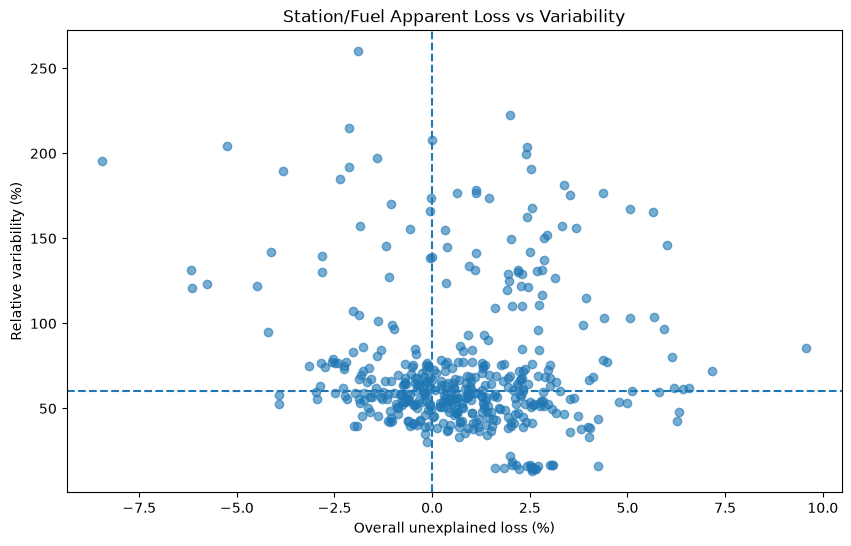

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(station_loss["loss_pct"], station_loss["relative_variability"], alpha=0.6)

plt.xlabel("Overall unexplained loss (%)")
plt.ylabel("Relative variability (%)")
plt.title("Station/Fuel Apparent Loss vs Variability")

plt.axvline(0, linestyle="--")
plt.axhline(station_loss["relative_variability"].median(), linestyle="--")

plt.show()

## B2 — Temperature and Apparent Loss

Temperature can affect fuel volume measurements. We therefore test whether daily temperature is associated with unexplained fuel loss before treating unusual balances as evidence of genuine loss.

In [109]:
reconciliation[["temperature_c", "unexplained_loss_l"]].describe()

,temperature_c,unexplained_loss_l
count,234808.000000,234808.000000
mean,25.998621,14.793256
std,3.459817,2067.761110
min,9.600000,-40271.700000
25%,23.700000,-4.100000
50%,26.000000,14.400000
75%,28.300000,34.200000
max,42.200000,40326.900000


In [110]:
reconciliation[["temperature_c", "unexplained_loss_l"]].corr()

,temperature_c,unexplained_loss_l
temperature_c,1.000000,-0.001661
unexplained_loss_l,-0.001661,1.000000


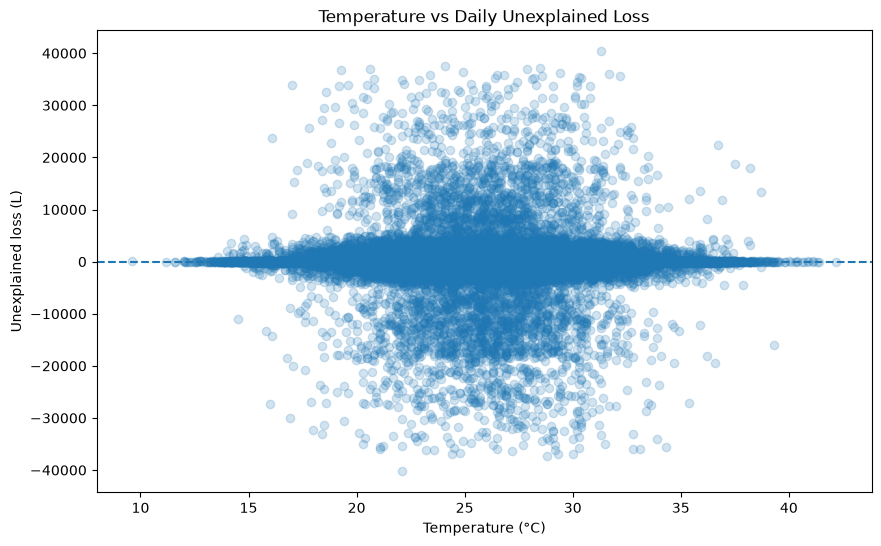

In [111]:
plt.figure(figsize=(10, 6))

plt.scatter(
    reconciliation["temperature_c"], reconciliation["unexplained_loss_l"], alpha=0.2
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Unexplained loss (L)")
plt.title("Temperature vs Daily Unexplained Loss")

plt.axhline(0, linestyle="--")

plt.show()

## B3 — Station-Level Anomaly Features

We now summarise each station's behaviour into features that can be compared across the network.

The goal is not to label stations as fraudulent. The features describe different aspects of station behaviour so that Stage C can identify unusual combinations of patterns.

In [116]:
station_features = (
    reconciliation.groupby("station_id")
    .agg(
        total_loss_l=("unexplained_loss_l", "sum"),
        total_throughput_l=("throughput_l", "sum"),
        loss_variability_l=("unexplained_loss_l", "std"),
        mean_daily_throughput_l=("throughput_l", "mean"),
        mean_temperature_c=("temperature_c", "mean"),
        temperature_variability_c=("temperature_c", "std"),
    )
    .reset_index()
)

station_features["loss_pct"] = (
    station_features["total_loss_l"] / station_features["total_throughput_l"] * 100
)

station_features["relative_variability"] = (
    station_features["loss_variability_l"]
    / station_features["mean_daily_throughput_l"]
    * 100
)

positive_loss_days = (
    reconciliation.assign(positive_loss=reconciliation["unexplained_loss_l"] > 0)
    .groupby("station_id")["positive_loss"]
    .mean()
)

station_features["positive_loss_rate"] = station_features["station_id"].map(
    positive_loss_days
)

In [117]:
station_features.shape

(150, 10)

In [118]:
station_features.describe()

,total_loss_l,total_throughput_l,loss_variability_l,mean_daily_throughput_l,mean_temperature_c,temperature_variability_c,loss_pct,relative_variability,positive_loss_rate
count,150.000000,1.500000e+02,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,23157.165667,4.472331e+06,1926.041460,2856.600300,25.998637,3.459298,0.499964,67.543511,0.701341
std,49425.280186,1.691066e+06,754.880119,1078.194547,0.088393,0.059192,1.048672,8.935687,0.071089
min,-91054.000000,2.348805e+06,644.666788,1500.834058,25.795483,3.333244,-1.949209,42.108025,0.533801
25%,-10019.437500,3.566289e+06,1438.068284,2276.365327,25.938505,3.417977,-0.271783,62.242755,0.663857
50%,18818.875000,3.634122e+06,1744.420916,2328.747196,25.989919,3.459245,0.403076,66.818521,0.683655
75%,47184.437500,5.463168e+06,2547.747044,3489.073357,26.054005,3.502283,1.195807,74.627905,0.751084
max,230593.100000,7.387605e+06,4128.102409,4711.482717,26.276836,3.611010,3.417149,92.118904,0.902423


In [119]:
station_features[
    [
        "loss_pct",
        "relative_variability",
        "positive_loss_rate",
        "mean_temperature_c",
        "temperature_variability_c",
    ]
].describe()

,loss_pct,relative_variability,positive_loss_rate,mean_temperature_c,temperature_variability_c
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,0.499964,67.543511,0.701341,25.998637,3.459298
std,1.048672,8.935687,0.071089,0.088393,0.059192
min,-1.949209,42.108025,0.533801,25.795483,3.333244
25%,-0.271783,62.242755,0.663857,25.938505,3.417977
50%,0.403076,66.818521,0.683655,25.989919,3.459245
75%,1.195807,74.627905,0.751084,26.054005,3.502283
max,3.417149,92.118904,0.902423,26.276836,3.611010


In [120]:
fuel_features = (
    period_reconciliation.groupby("station_id")
    .agg(
        mean_fuel_loss_pct=("loss_pct", "mean"),
        fuel_loss_variability=("loss_pct", "std"),
        max_fuel_loss_pct=("loss_pct", "max"),
    )
    .reset_index()
)

station_features = station_features.merge(fuel_features, on="station_id", how="left")

In [121]:
station_features.shape

(150, 13)

In [122]:
station_features[
    [
        "station_id",
        "loss_pct",
        "relative_variability",
        "positive_loss_rate",
        "mean_fuel_loss_pct",
        "fuel_loss_variability",
        "max_fuel_loss_pct",
    ]
].head()

,station_id,loss_pct,relative_variability,positive_loss_rate,mean_fuel_loss_pct,fuel_loss_variability,max_fuel_loss_pct
0,ST-001,1.691220,79.600200,0.678411,1.386482,0.895855,1.966950
1,ST-002,2.261079,61.273630,0.586998,1.740425,1.244836,2.496970
2,ST-003,-0.325297,47.494162,0.728737,1.667490,5.435015,7.919901
3,ST-004,1.177808,63.954366,0.731629,0.824259,1.543677,2.212369
4,ST-005,0.371562,56.529521,0.590822,1.053964,1.468772,2.749948


In [123]:
station_features[
    ["station_id", "loss_pct", "max_fuel_loss_pct", "fuel_loss_variability"]
].sort_values("max_fuel_loss_pct", ascending=False).head(10)

,station_id,loss_pct,max_fuel_loss_pct,fuel_loss_variability
77,ST-078,1.558693,9.558446,5.162588
42,ST-043,0.103776,8.604774,6.172272
147,ST-148,1.703191,8.316864,4.464644
43,ST-044,0.446200,8.274348,4.846306
2,ST-003,-0.325297,7.919901,5.435015
136,ST-137,1.015231,7.851710,4.206857
38,ST-039,1.350418,7.705291,3.824785
59,ST-060,1.380587,7.633025,3.545421
126,ST-127,0.681031,7.616879,4.130417
7,ST-008,0.223179,7.297966,4.742229


## B4 — Stage B Conclusion

Stage B shows that apparent fuel loss varies across stations in both
magnitude and consistency.

Station-level features were created to capture overall loss, variability,
the frequency of positive apparent loss, and differences between fuel
types.

Some stations have a relatively ordinary overall loss percentage but
show unusually high apparent loss for one fuel. This shows why looking
only at the overall station balance could hide important patterns.

Temperature was also tested as a possible explanation for daily
unexplained loss. The simple correlation was approximately zero, so the
data does not show a meaningful linear relationship between temperature
and unexplained loss. This does not prove that temperature has no physical
effect on fuel measurements; it means that the relationship is not clearly
visible in this dataset using this simple test.

The results do not provide evidence of deliberate fuel loss by
themselves. They instead provide a set of behavioural features that can
be used to identify unusual stations.

Stage C will use these features with multiple anomaly-detection methods
and compare whether different methods identify the same stations.

In [124]:
station_features.isna().sum()

station_id                   0
total_loss_l                 0
total_throughput_l           0
loss_variability_l           0
mean_daily_throughput_l      0
mean_temperature_c           0
temperature_variability_c    0
loss_pct                     0
relative_variability         0
positive_loss_rate           0
mean_fuel_loss_pct           0
fuel_loss_variability        0
max_fuel_loss_pct            0
dtype: int64

In [125]:
stage_c_features = station_features[
    [
        "loss_pct",
        "relative_variability",
        "positive_loss_rate",
        "mean_fuel_loss_pct",
        "fuel_loss_variability",
        "max_fuel_loss_pct",
    ]
].copy()

stage_c_features.describe()

,loss_pct,relative_variability,positive_loss_rate,mean_fuel_loss_pct,fuel_loss_variability,max_fuel_loss_pct
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,0.499964,67.543511,0.701341,0.858294,2.602380,3.403314
std,1.048672,8.935687,0.071089,1.663820,1.446838,2.306735
min,-1.949209,42.108025,0.533801,-4.431082,0.103516,-1.315694
25%,-0.271783,62.242755,0.663857,-0.087727,1.493247,2.148200
50%,0.403076,66.818521,0.683655,0.954362,2.430242,2.950953
75%,1.195807,74.627905,0.751084,1.937099,3.474378,5.061294
max,3.417149,92.118904,0.902423,3.852930,6.928188,9.558446
